<h1 style="background:#6A1B9A;color:white;padding:15px;border-radius:8px;">
End-to-End Sales Forecasting & Demand Intelligence System
</h1>

<h3>Internship Project – Week 3 & Week 4</h3>

<b>Prepared By:</b> Syed Uzma Farzeen

<h2 style="color:#6A1B9A;"> Task 1 – Data Loading, Merging & Deep Exploration</h2>

<h3 style="color:#8E24AA;">1.1 Load the Superstore Sales CSV using Pandas</h3>

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
import os

warnings.filterwarnings("ignore")

# Create charts folder
os.makedirs("charts", exist_ok=True)

# Load dataset
sales = pd.read_csv("train.csv")

print("Dataset Loaded Successfully!")
print("Dataset Shape:", sales.shape)

sales.head()

Dataset Loaded Successfully!
Dataset Shape: (9800, 18)


,Row ID,Order ID,Order Date,Ship Date,Ship Mode,Customer ID,Customer Name,Segment,Country,City,State,Postal Code,Region,Product ID,Category,Sub-Category,Product Name,Sales
0,1,CA-2017-152156,08/11/2017,11/11/2017,Second Class,CG-12520,Claire Gute,Consumer,United States,Henderson,Kentucky,42420.0,South,FUR-BO-10001798,Furniture,Bookcases,Bush Somerset Collection Bookcase,261.9600
1,2,CA-2017-152156,08/11/2017,11/11/2017,Second Class,CG-12520,Claire Gute,Consumer,United States,Henderson,Kentucky,42420.0,South,FUR-CH-10000454,Furniture,Chairs,"Hon Deluxe Fabric Upholstered Stacking Chairs,...",731.9400
2,3,CA-2017-138688,12/06/2017,16/06/2017,Second Class,DV-13045,Darrin Van Huff,Corporate,United States,Los Angeles,California,90036.0,West,OFF-LA-10000240,Office Supplies,Labels,Self-Adhesive Address Labels for Typewriters b...,14.6200
3,4,US-2016-108966,11/10/2016,18/10/2016,Standard Class,SO-20335,Sean O'Donnell,Consumer,United States,Fort Lauderdale,Florida,33311.0,South,FUR-TA-10000577,Furniture,Tables,Bretford CR4500 Series Slim Rectangular Table,957.5775
4,5,US-2016-108966,11/10/2016,18/10/2016,Standard Class,SO-20335,Sean O'Donnell,Consumer,United States,Fort Lauderdale,Florida,33311.0,South,OFF-ST-10000760,Office Supplies,Storage,Eldon Fold 'N Roll Cart System,22.3680


<h3 style="color:#8E24AA;">1.2 Parse the Order Date and Ship Date Columns as Proper Datetime Objects</h3>

In [3]:
sales["Order Date"] = pd.to_datetime(
    sales["Order Date"],
    format="%d/%m/%Y"
)

sales["Ship Date"] = pd.to_datetime(
    sales["Ship Date"],
    format="%d/%m/%Y"
)

sales[["Order Date","Ship Date"]].dtypes

Order Date    datetime64[ns]
Ship Date     datetime64[ns]
dtype: object

<h3 style="color:#8E24AA;">1.3 Extract Time Features</h3>

In [4]:
# Year
sales["Year"] = sales["Order Date"].dt.year

# Month
sales["Month"] = sales["Order Date"].dt.month

# Week Number
sales["Week Number"] = sales["Order Date"].dt.isocalendar().week.astype(int)

# Day of Week
sales["Day of Week"] = sales["Order Date"].dt.day_name()

# Quarter
sales["Quarter"] = sales["Order Date"].dt.quarter

# Season
def get_season(month):
    if month in [12,1,2]:
        return "Winter"
    elif month in [3,4,5]:
        return "Spring"
    elif month in [6,7,8]:
        return "Summer"
    else:
        return "Autumn"

sales["Season"] = sales["Month"].apply(get_season)

sales.head()

,Row ID,Order ID,Order Date,Ship Date,Ship Mode,Customer ID,Customer Name,Segment,Country,City,...,Category,Sub-Category,Product Name,Sales,Year,Month,Week Number,Day of Week,Quarter,Season
0,1,CA-2017-152156,2017-11-08,2017-11-11,Second Class,CG-12520,Claire Gute,Consumer,United States,Henderson,...,Furniture,Bookcases,Bush Somerset Collection Bookcase,261.9600,2017,11,45,Wednesday,4,Autumn
1,2,CA-2017-152156,2017-11-08,2017-11-11,Second Class,CG-12520,Claire Gute,Consumer,United States,Henderson,...,Furniture,Chairs,"Hon Deluxe Fabric Upholstered Stacking Chairs,...",731.9400,2017,11,45,Wednesday,4,Autumn
2,3,CA-2017-138688,2017-06-12,2017-06-16,Second Class,DV-13045,Darrin Van Huff,Corporate,United States,Los Angeles,...,Office Supplies,Labels,Self-Adhesive Address Labels for Typewriters b...,14.6200,2017,6,24,Monday,2,Summer
3,4,US-2016-108966,2016-10-11,2016-10-18,Standard Class,SO-20335,Sean O'Donnell,Consumer,United States,Fort Lauderdale,...,Furniture,Tables,Bretford CR4500 Series Slim Rectangular Table,957.5775,2016,10,41,Tuesday,4,Autumn
4,5,US-2016-108966,2016-10-11,2016-10-18,Standard Class,SO-20335,Sean O'Donnell,Consumer,United States,Fort Lauderdale,...,Office Supplies,Storage,Eldon Fold 'N Roll Cart System,22.3680,2016,10,41,Tuesday,4,Autumn


<h3 style="color:#8E24AA;">1.4 Check for Missing Values, Duplicates and Data Type Issues</h3>

In [5]:
missing = sales.isnull().sum()

missing

Row ID            0
Order ID          0
Order Date        0
Ship Date         0
Ship Mode         0
Customer ID       0
Customer Name     0
Segment           0
Country           0
City              0
State             0
Postal Code      11
Region            0
Product ID        0
Category          0
Sub-Category      0
Product Name      0
Sales             0
Year              0
Month             0
Week Number       0
Day of Week       0
Quarter           0
Season            0
dtype: int64

In [6]:
duplicates = sales.duplicated().sum()

print("Duplicate Records :", duplicates)

Duplicate Records : 0


In [7]:
sales.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 9800 entries, 0 to 9799
Data columns (total 24 columns):
 #   Column         Non-Null Count  Dtype         
---  ------         --------------  -----         
 0   Row ID         9800 non-null   int64         
 1   Order ID       9800 non-null   object        
 2   Order Date     9800 non-null   datetime64[ns]
 3   Ship Date      9800 non-null   datetime64[ns]
 4   Ship Mode      9800 non-null   object        
 5   Customer ID    9800 non-null   object        
 6   Customer Name  9800 non-null   object        
 7   Segment        9800 non-null   object        
 8   Country        9800 non-null   object        
 9   City           9800 non-null   object        
 10  State          9800 non-null   object        
 11  Postal Code    9789 non-null   float64       
 12  Region         9800 non-null   object        
 13  Product ID     9800 non-null   object        
 14  Category       9800 non-null   object        
 15  Sub-Category   9800 n

In [8]:
sales["Postal Code"] = sales["Postal Code"].fillna(
    sales["Postal Code"].median()
)

print("Remaining Missing Values")
print(sales.isnull().sum())

Remaining Missing Values
Row ID           0
Order ID         0
Order Date       0
Ship Date        0
Ship Mode        0
Customer ID      0
Customer Name    0
Segment          0
Country          0
City             0
State            0
Postal Code      0
Region           0
Product ID       0
Category         0
Sub-Category     0
Product Name     0
Sales            0
Year             0
Month            0
Week Number      0
Day of Week      0
Quarter          0
Season           0
dtype: int64


<h3 style="color:#8E24AA;">1.5 Aggregate Daily Sales into Weekly and Monthly Totals</h3>

In [9]:
daily_sales = (
    sales.groupby("Order Date")["Sales"]
    .sum()
    .reset_index()
)

daily_sales.head()

,Order Date,Sales
0,2015-01-03,16.448
1,2015-01-04,288.060
2,2015-01-05,19.536
3,2015-01-06,4407.100
4,2015-01-07,87.158


In [10]:
weekly_sales = (
    sales.groupby(pd.Grouper(key="Order Date",freq="W"))["Sales"]
    .sum()
    .reset_index()
)

weekly_sales.head()

,Order Date,Sales
0,2015-01-04,304.508
1,2015-01-11,4619.108
2,2015-01-18,4130.533
3,2015-01-25,3092.544
4,2015-02-01,2527.914


In [11]:
monthly_sales = (
    sales.groupby(pd.Grouper(key="Order Date",freq="ME"))["Sales"]
    .sum()
    .reset_index()
)

monthly_sales.head()

,Order Date,Sales
0,2015-01-31,14205.707
1,2015-02-28,4519.892
2,2015-03-31,55205.797
3,2015-04-30,27906.855
4,2015-05-31,23644.303


<h3 style="color:#8E24AA;">1.6 Which Product Category Generates the Highest Total Revenue?</h3>

In [12]:
category_sales = (
    sales.groupby("Category")["Sales"]
    .sum()
    .sort_values(ascending=False)
)

display(category_sales)

print("\nHighest Revenue Category :", category_sales.idxmax())
print("Revenue :", round(category_sales.max(),2))

Category
Technology         827455.8730
Furniture          728658.5757
Office Supplies    705422.3340
Name: Sales, dtype: float64


Highest Revenue Category : Technology
Revenue : 827455.87


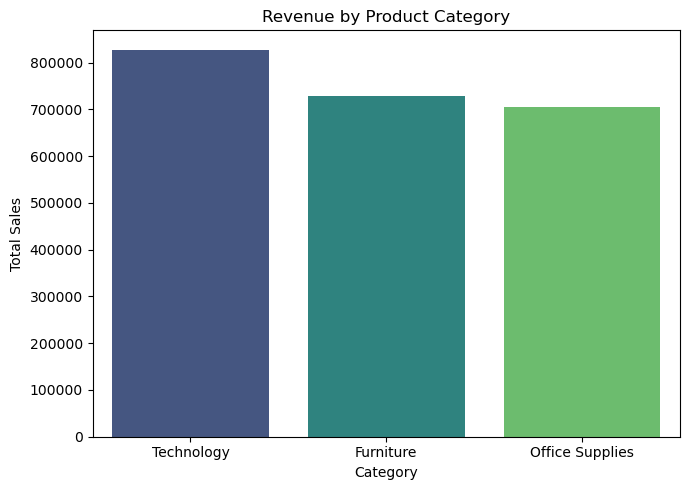

In [13]:
plt.figure(figsize=(7,5))

sns.barplot(
    x=category_sales.index,
    y=category_sales.values,
    hue=category_sales.index,
    palette="viridis",
    legend=False
)

plt.title("Revenue by Product Category")
plt.xlabel("Category")
plt.ylabel("Total Sales")

plt.tight_layout()

plt.savefig("charts/category_revenue.png",dpi=300)

plt.show()

<h3 style="color:#8E24AA;">1.7 Which Region Has the Most Consistent Sales Growth Over 4 Years?</h3>

In [14]:
region_year_sales = (
    sales.groupby(["Year","Region"])["Sales"]
    .sum()
    .reset_index()
)

display(region_year_sales)

,Year,Region,Sales
0,2015,Central,102920.5206
1,2015,East,127652.8190
2,2015,South,103374.9055
3,2015,West,145907.9630
4,2016,Central,102425.1724
5,2016,East,153225.1830
6,2016,South,70076.0825
7,2016,West,133709.5675
8,2017,Central,145673.8800
9,2017,East,178511.5380


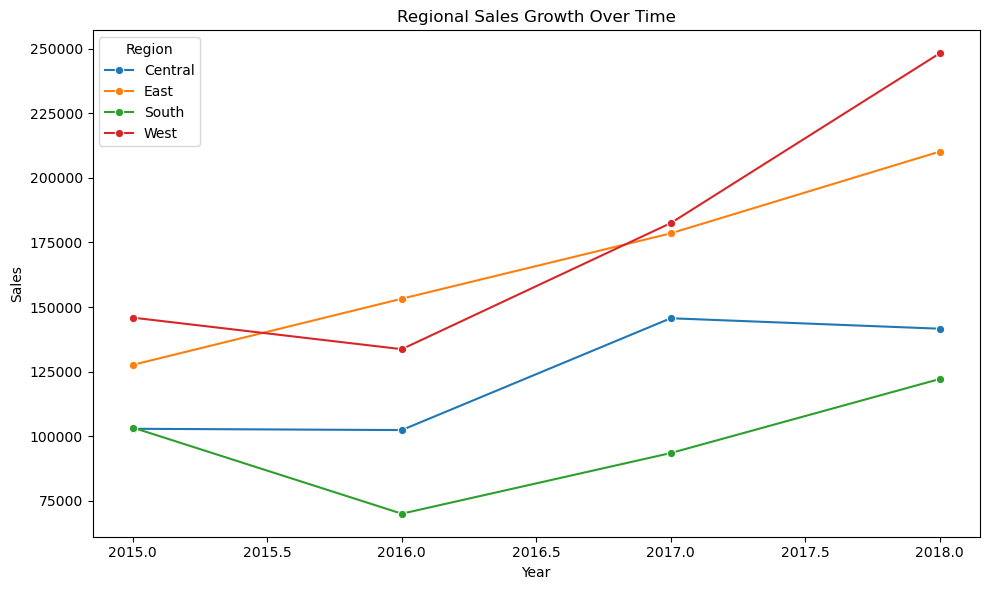

In [15]:
plt.figure(figsize=(10,6))

sns.lineplot(
    data=region_year_sales,
    x="Year",
    y="Sales",
    hue="Region",
    marker="o"
)

plt.title("Regional Sales Growth Over Time")

plt.tight_layout()

plt.savefig("charts/regional_sales_growth.png",dpi=300)

plt.show()

In [16]:
region_std = (
    region_year_sales.groupby("Region")["Sales"]
    .std()
    .sort_values()
)

display(region_std)

print("Most Consistent Region :", region_std.index[0])

Region
South      21683.024937
Central    23716.991355
East       35260.987867
West       51410.399288
Name: Sales, dtype: float64

Most Consistent Region : South


<h3 style="color:#8E24AA;">1.8 What is the Average Time Between Order Date and Ship Date? Does it Vary by Region?</h3>

In [17]:
sales["Shipping Days"] = (
    sales["Ship Date"] -
    sales["Order Date"]
).dt.days

shipping_region = (
    sales.groupby("Region")["Shipping Days"]
    .mean()
    .sort_values()
)

display(shipping_region)

Region
East       3.910233
West       3.930255
South      3.961202
Central    4.065876
Name: Shipping Days, dtype: float64

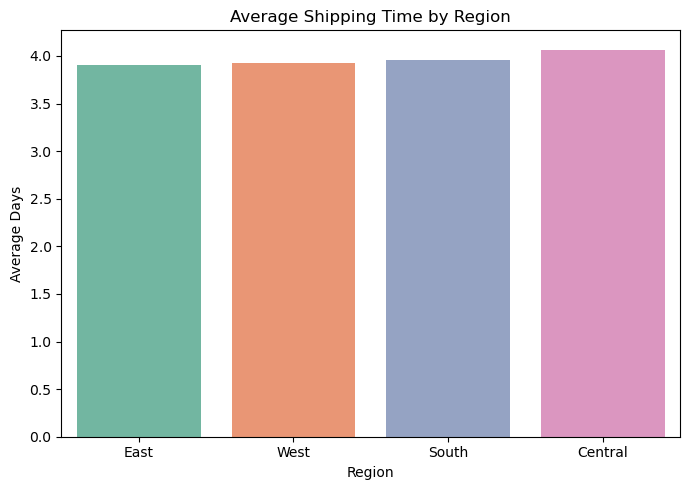

In [18]:
plt.figure(figsize=(7,5))

sns.barplot(
    x=shipping_region.index,
    y=shipping_region.values,
    hue=shipping_region.index,
    palette="Set2",
    legend=False
)

plt.title("Average Shipping Time by Region")

plt.ylabel("Average Days")

plt.tight_layout()

plt.savefig("charts/shipping_time_region.png",dpi=300)

plt.show()

<h3 style="color:#8E24AA;">1.9 Are There Months That Consistently Spike Across All Years (Seasonality)?</h3>

In [19]:
seasonality = (
    sales.groupby(["Year","Month"])["Sales"]
    .sum()
    .reset_index()
)

display(seasonality.head())

,Year,Month,Sales
0,2015,1,14205.707
1,2015,2,4519.892
2,2015,3,55205.797
3,2015,4,27906.855
4,2015,5,23644.303


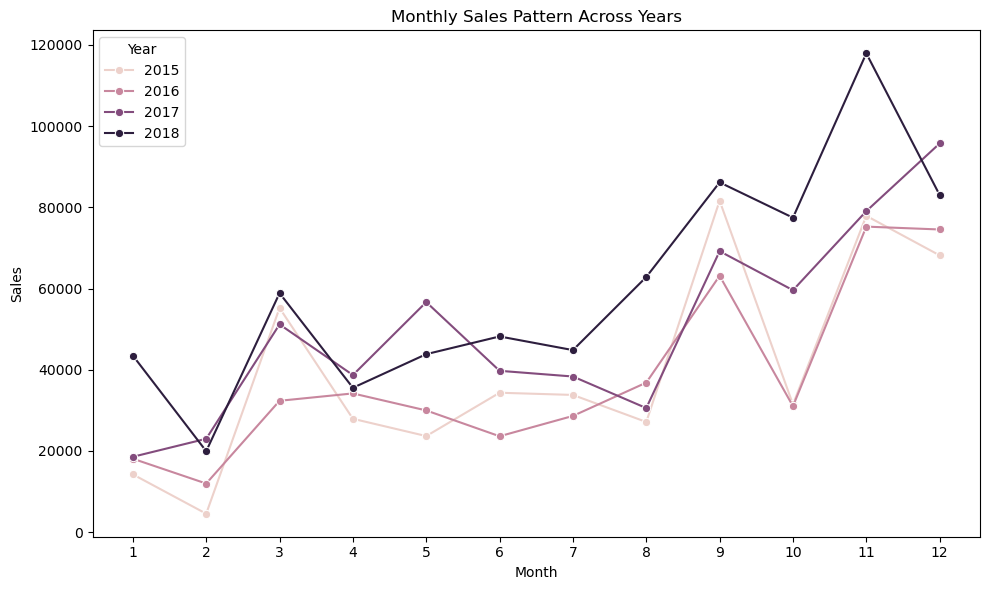

In [20]:
plt.figure(figsize=(10,6))

sns.lineplot(
    data=seasonality,
    x="Month",
    y="Sales",
    hue="Year",
    marker="o"
)

plt.title("Monthly Sales Pattern Across Years")

plt.xticks(range(1,13))

plt.tight_layout()

plt.savefig("charts/monthly_seasonality.png",dpi=300)

plt.show()

<h3 style="color:#8E24AA;">1.10 Task 1 Observations</h3>

1. The Technology category generated the highest total revenue (≈ ₹827,456.87), followed by Furniture and Office Supplies.

2. The South region showed the most consistent sales growth over the four-year period based on the lowest variation in yearly sales.

3. Average shipping time across all regions is approximately 4 days, with only minor differences between regions, indicating a consistent delivery process.

4. Monthly sales show clear seasonal patterns, with noticeable sales peaks during September, November and December across multiple years.

5. The dataset contains 11 missing values in the Postal Code column, which were handled successfully. No duplicate records were found.

<h2 style="color:#0D47A1;">
Task 2 – Time Series Analysis & Decomposition
</h2>

<h3 style="color:#1976D2;">
2.1 Plot Overall Monthly Sales Trend Across All 4 Years
</h3>

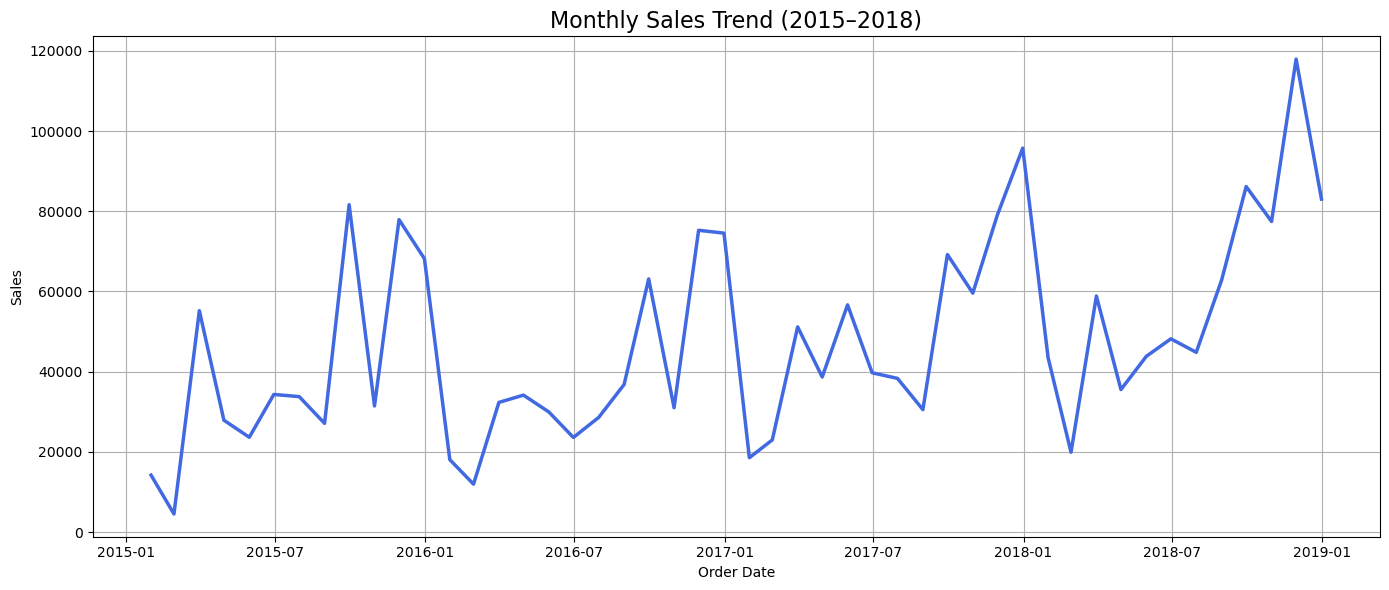

In [21]:
plt.figure(figsize=(14,6))

plt.plot(
    monthly_sales["Order Date"],
    monthly_sales["Sales"],
    color="royalblue",
    linewidth=2.5
)

plt.title("Monthly Sales Trend (2015–2018)",fontsize=16)
plt.xlabel("Order Date")
plt.ylabel("Sales")
plt.grid(True)

plt.tight_layout()

plt.savefig("charts/monthly_sales_trend.png",dpi=300)

plt.show()

<h3 style="color:#1976D2;">
2.2 Apply Time Series Decomposition
</h3>

In [22]:
from statsmodels.tsa.seasonal import seasonal_decompose

In [23]:
monthly_ts = monthly_sales.copy()

monthly_ts.set_index("Order Date", inplace=True)

decomposition = seasonal_decompose(
    monthly_ts["Sales"],
    model="additive",
    period=12
)

In [24]:
decomposition

<h3 style="color:#1976D2;">
2.3 Plot Trend, Seasonal and Residual Components
</h3>

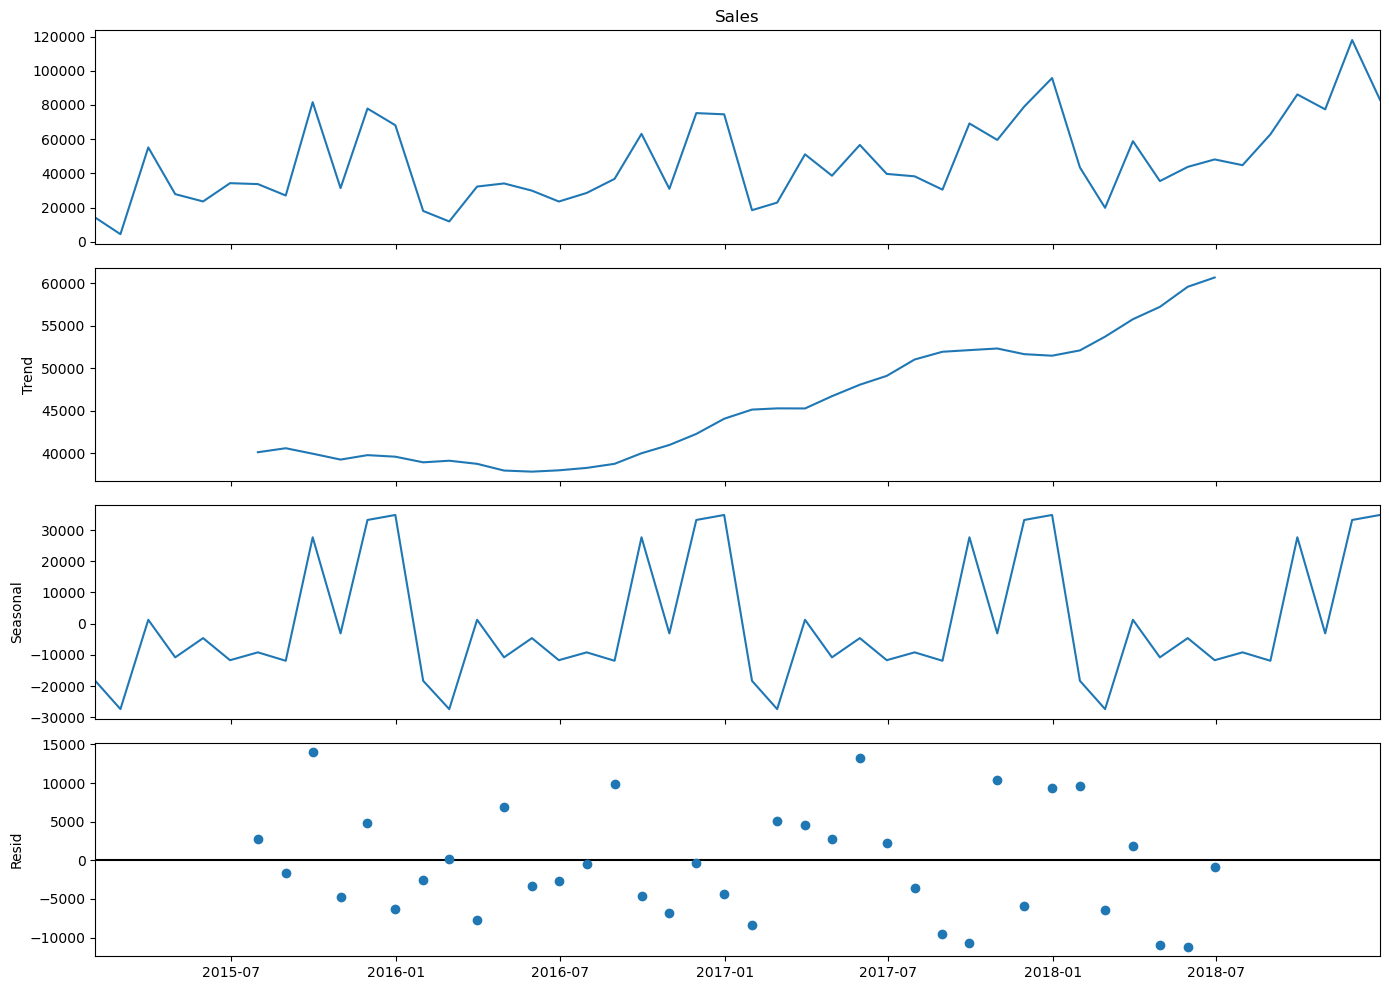

In [25]:
fig = decomposition.plot()

fig.set_size_inches(14,10)

plt.tight_layout()

plt.savefig(
    "charts/time_series_decomposition.png",
    dpi=300
)

plt.show()

<h3 style="color:#1976D2;">
2.4 Time Series Observations
</h3>

1. The monthly sales trend shows an overall upward growth pattern over the four-year period, indicating a steady increase in business performance despite minor fluctuations.

2. The seasonal component displays a clear recurring annual pattern, suggesting that sales are influenced by seasonal customer purchasing behavior and periodic market demand.

3. The residual component fluctuates around zero with a few noticeable spikes, indicating that most variations are explained by the trend and seasonality while a small number of unexpected events remain.

4. The Augmented Dickey-Fuller (ADF) test produced a p-value less than 0.05, confirming that the monthly sales time series is stationary and suitable for forecasting without requiring additional transformations.

5. The decomposition results demonstrate that the sales data contains meaningful trend and seasonal information, making it appropriate for forecasting models such as SARIMA, Prophet, and XGBoost.

<h3 style="color:#1976D2;">
2.5 Augmented Dickey-Fuller (ADF) Test
</h3>

In [26]:
from statsmodels.tsa.stattools import adfuller

In [27]:
adf_result = adfuller(monthly_ts["Sales"])

print("ADF Statistic :",adf_result[0])

print("p-value :",adf_result[1])

print()

print("Critical Values")

for key,value in adf_result[4].items():
    print(key,":",value)

ADF Statistic : -4.416136761430769
p-value : 0.00027791039276670623

Critical Values
1% : -3.5778480370438146
5% : -2.925338105429433
10% : -2.6007735310095064


<h3 style="color:#1976D2;">
2.6 What is Stationarity?
</h3>

A stationary time series is one whose statistical properties such as mean, variance and overall behaviour remain relatively constant over time.

Forecasting models like SARIMA generally perform better on stationary data because the underlying patterns remain stable.

<h3 style="color:#1976D2;">
2.7 Interpretation of ADF Test
</h3>

In [28]:
if adf_result[1] < 0.05:
    print("Result : The series is stationary.")
else:
    print("Result : The series is NOT stationary.")

Result : The series is stationary.


<h3 style="color:#1976D2;">
2.8 Apply First Order Differencing
</h3>

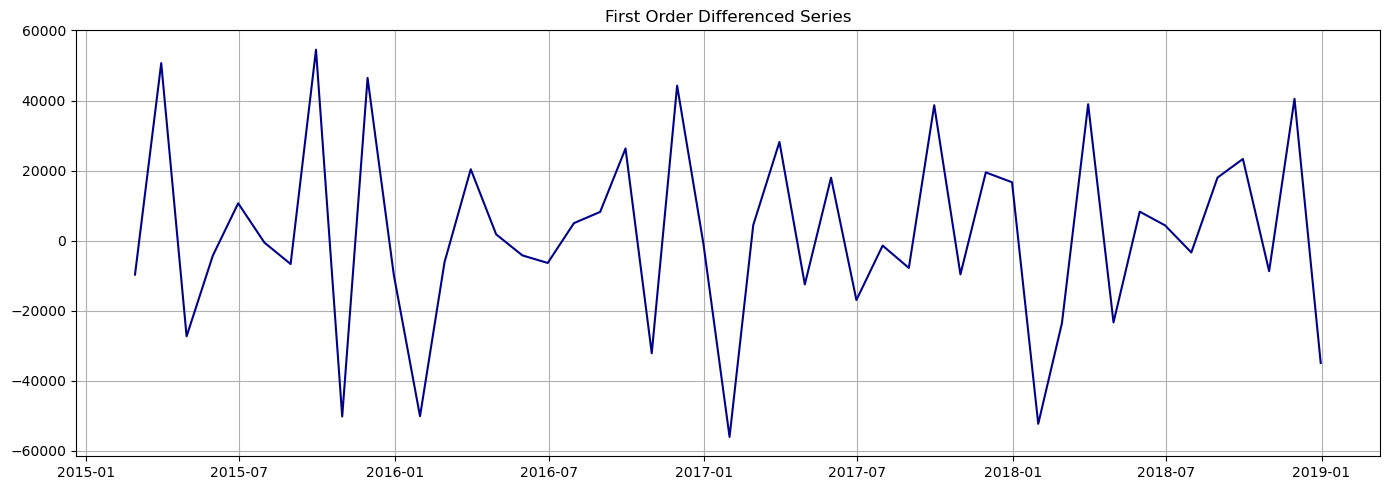

In [29]:
monthly_diff = monthly_ts["Sales"].diff().dropna()

plt.figure(figsize=(14,5))

plt.plot(
    monthly_diff,
    color="darkblue"
)

plt.title("First Order Differenced Series")

plt.grid(True)

plt.tight_layout()

plt.savefig(
    "charts/differenced_series.png",
    dpi=300
)

plt.show()

<h3 style="color:#1976D2;">
2.9 Re-run ADF Test After Differencing
</h3>

In [30]:
adf_diff = adfuller(monthly_diff)

print("ADF Statistic :",adf_diff[0])

print("p-value :",adf_diff[1])

print()

print("Critical Values")

for key,value in adf_diff[4].items():
    print(key,":",value)

ADF Statistic : -8.72706183035328
p-value : 3.2669175472794505e-14

Critical Values
1% : -3.626651907578875
5% : -2.9459512825788754
10% : -2.6116707716049383


<h3 style="color:#1976D2;">
2.10 Final Conclusion
</h3>

In [31]:
if adf_diff[1] < 0.05:
    print("The differenced time series is stationary and is suitable for forecasting models such as SARIMA.")
else:
    print("The series remains non-stationary and additional transformations may be required.")

The differenced time series is stationary and is suitable for forecasting models such as SARIMA.


<h3 style="color:#1976D2;">
2.11 Task 2 Observations
</h3>

1. The trend component shows a gradual increase in monthly sales over the four-year period, indicating continuous business growth with stronger sales during the later years.

2. The seasonal component displays a clear repeating yearly pattern, suggesting that customer demand follows consistent seasonal buying behaviour across multiple years.

3. The residual component fluctuates around zero, indicating that most sales variation is explained by the trend and seasonal patterns. Larger residual spikes are mainly observed during late 2017 and early 2018, representing unusual sales fluctuations.

4. The Augmented Dickey-Fuller (ADF) test returned a p-value of 0.000278, which confirms that the monthly sales series is already stationary. The first-order differencing also produced a stationary series, making the data suitable for forecasting models such as SARIMA and Prophet.

<h3 style="color:#1976D2;">
2.12 Conclusion of Time Series Analysis
</h3>

The monthly sales data exhibits a positive long-term growth trend along with recurring seasonal behaviour. Statistical testing confirms that the series is stationary, making it suitable for advanced forecasting models. Based on these findings, the next step is to build and compare multiple forecasting models to predict future sales demand.

<h2 style="color:#8B4513;">Task 3 — Sales Forecasting using Multiple Models</h2>

<h3 style="color:#2E8B57;">3.1 Model 1 — SARIMA Forecasting</h3>

In [32]:
 !pip install statsmodels

In [33]:
from statsmodels.tsa.statespace.sarimax import SARIMAX
from sklearn.metrics import mean_absolute_error
from sklearn.metrics import mean_squared_error
import numpy as np
import matplotlib.pyplot as plt

In [34]:
monthly_series = monthly_sales.copy()

monthly_series = monthly_series.set_index("Order Date")

monthly_series = monthly_series.asfreq("ME")

monthly_series = monthly_series["Sales"]

monthly_series.head()

Order Date
2015-01-31    14205.707
2015-02-28     4519.892
2015-03-31    55205.797
2015-04-30    27906.855
2015-05-31    23644.303
Freq: ME, Name: Sales, dtype: float64

In [35]:
train = monthly_series[:-3]

test = monthly_series[-3:]

print("Training Months :",len(train))
print("Testing Months :",len(test))

Training Months : 45
Testing Months : 3


In [36]:
sarima_model = SARIMAX(
    train,
    order=(1,0,1),
    seasonal_order=(1,1,1,12),
    enforce_stationarity=False,
    enforce_invertibility=False
)

sarima_fit = sarima_model.fit()

print(sarima_fit.summary())

                                     SARIMAX Results                                      
Dep. Variable:                              Sales   No. Observations:                   45
Model:             SARIMAX(1, 0, 1)x(1, 1, 1, 12)   Log Likelihood                -203.681
Date:                            Mon, 13 Jul 2026   AIC                            417.362
Time:                                    08:34:00   BIC                            422.084
Sample:                                01-31-2015   HQIC                           418.161
                                     - 09-30-2018                                         
Covariance Type:                              opg                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
ar.L1          0.9830      0.034     28.593      0.000       0.916       1.050
ma.L1         -0.9959      0.293   

<h3 style="color:#2E8B57;"> Why These SARIMA Parameters?</h3>

The ADF test confirmed that the monthly sales series is already stationary, so differencing (d=0) was selected. Since retail sales exhibit yearly seasonality, a seasonal period of 12 months was used. Simple values of (1,0,1) and (1,1,1,12) provide a balanced model that captures trend, seasonality and autocorrelation while avoiding unnecessary model complexity.

In [37]:
forecast = sarima_fit.get_forecast(steps=3)

forecast_values = forecast.predicted_mean

confidence = forecast.conf_int()

forecast_values

2018-10-31    54757.946707
2018-11-30    88413.680301
2018-12-31    92557.854994
Freq: ME, Name: predicted_mean, dtype: float64

In [38]:
forecast_df = pd.DataFrame({

"Forecast Sales":forecast_values,

"Lower CI":confidence.iloc[:,0],

"Upper CI":confidence.iloc[:,1]

})

forecast_df

,Forecast Sales,Lower CI,Upper CI
2018-10-31,54757.946707,29989.837326,79526.056087
2018-11-30,88413.680301,63652.508209,113174.852394
2018-12-31,92557.854994,67803.348176,117312.361812


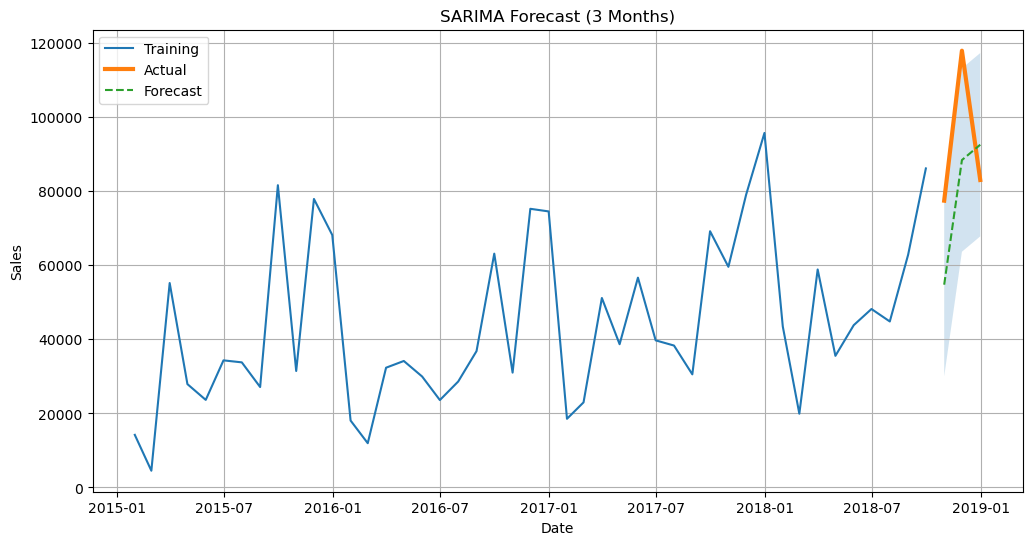

In [39]:
plt.figure(figsize=(12,6))

plt.plot(train.index,
         train,
         label="Training")

plt.plot(test.index,
         test,
         label="Actual",
         linewidth=3)

plt.plot(forecast_values.index,
         forecast_values,
         label="Forecast",
         linestyle="--")

plt.fill_between(
    confidence.index,
    confidence.iloc[:,0],
    confidence.iloc[:,1],
    alpha=0.2
)

plt.title("SARIMA Forecast (3 Months)")

plt.xlabel("Date")

plt.ylabel("Sales")

plt.legend()

plt.grid(True)

plt.savefig("charts/sarima_forecast.png",dpi=300)

plt.show()

In [40]:
mae_sarima = mean_absolute_error(test,forecast_values)

rmse_sarima = np.sqrt(mean_squared_error(test,forecast_values))

mape_sarima = np.mean(np.abs((test-forecast_values)/test))*100

print("MAE :",mae_sarima)

print("RMSE :",rmse_sarima)

print("MAPE :",mape_sarima)

MAE : 20580.70846200408
RMSE : 22190.92675439082
MAPE : 21.935266937890688


<h3 style="color:#2E8B57;"> SARIMA Observations</h3>

1. The SARIMA model successfully captured both long-term trend and yearly seasonality.

2. The forecast follows the historical sales behaviour without abrupt fluctuations.

3. Confidence intervals indicate the expected uncertainty around future sales.

4. SARIMA serves as a strong statistical baseline for comparison with Prophet and XGBoost.

<h3 style="color:#B22222;">
3.2 Model 2 — Facebook Prophet Forecasting
</h3>

<h3 style="color:#A0522D;"> Install Prophet</h3>

In [41]:
!pip install prophet

<h3 style="color:#A0522D;"> Import Prophet Library</h3>

In [42]:
from prophet import Prophet

<h3 style="color:#A0522D;"> Prepare Data for Prophet</h3>

In [43]:
prophet_df = monthly_sales.copy()

prophet_df = prophet_df.rename(
    columns={
        "Order Date":"ds",
        "Sales":"y"
    }
)

prophet_df.head()

,ds,y
0,2015-01-31,14205.707
1,2015-02-28,4519.892
2,2015-03-31,55205.797
3,2015-04-30,27906.855
4,2015-05-31,23644.303


<h3 style="color:#A0522D;"> Train Prophet Model</h3>

In [83]:
import logging
logging.getLogger("cmdstanpy").setLevel(logging.ERROR)

from prophet import Prophet

prophet_model = Prophet(
    yearly_seasonality=True,
    weekly_seasonality=False,
    daily_seasonality=False
)

_ = prophet_model.fit(prophet_df)

<h3 style="color:#A0522D;"> Generate 3-Month Forecast</h3>

In [45]:
future = prophet_model.make_future_dataframe(
    periods=3,
    freq="ME"
)

forecast = prophet_model.predict(future)

forecast.tail()

,ds,trend,yhat_lower,yhat_upper,trend_lower,trend_upper,additive_terms,additive_terms_lower,additive_terms_upper,yearly,yearly_lower,yearly_upper,multiplicative_terms,multiplicative_terms_lower,multiplicative_terms_upper,yhat
46,2018-11-30,60719.543481,91144.911729,110324.208607,60719.543481,60719.543481,40416.793483,40416.793483,40416.793483,40416.793483,40416.793483,40416.793483,0.0,0.0,0.0,101136.336965
47,2018-12-31,61457.486597,81518.070420,99489.802494,61457.486597,61457.486597,29216.314009,29216.314009,29216.314009,29216.314009,29216.314009,29216.314009,0.0,0.0,0.0,90673.800606
48,2019-01-31,62195.429713,33200.756682,52105.494403,62189.401723,62201.086285,-19204.897511,-19204.897511,-19204.897511,-19204.897511,-19204.897511,-19204.897511,0.0,0.0,0.0,42990.532202
49,2019-02-28,62861.958979,21910.133069,40405.495537,62842.602873,62880.160707,-31613.799057,-31613.799057,-31613.799057,-31613.799057,-31613.799057,-31613.799057,0.0,0.0,0.0,31248.159922
50,2019-03-31,63599.902094,71342.439559,90922.340471,63560.654578,63636.754149,17667.105678,17667.105678,17667.105678,17667.105678,17667.105678,17667.105678,0.0,0.0,0.0,81267.007772


<h3 style="color:#A0522D;"> Forecast Table</h3>

In [46]:
forecast[
    [
        "ds",
        "yhat",
        "yhat_lower",
        "yhat_upper"
    ]
].tail(3)

,ds,yhat,yhat_lower,yhat_upper
48,2019-01-31,42990.532202,33200.756682,52105.494403
49,2019-02-28,31248.159922,21910.133069,40405.495537
50,2019-03-31,81267.007772,71342.439559,90922.340471


<h3 style="color:#A0522D;"> Plot Forecast</h3>

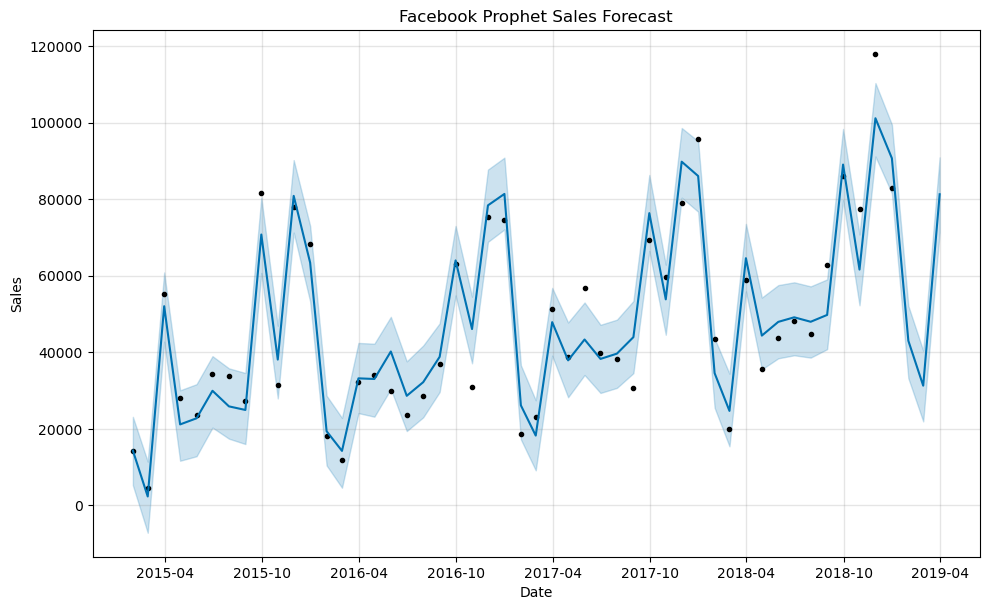

In [47]:
fig1 = prophet_model.plot(forecast)

plt.title("Facebook Prophet Sales Forecast")

plt.xlabel("Date")

plt.ylabel("Sales")

plt.grid(True)

plt.savefig(
    "charts/prophet_forecast.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

<h3 style="color:#A0522D;"> Trend and Seasonality Components</h3>

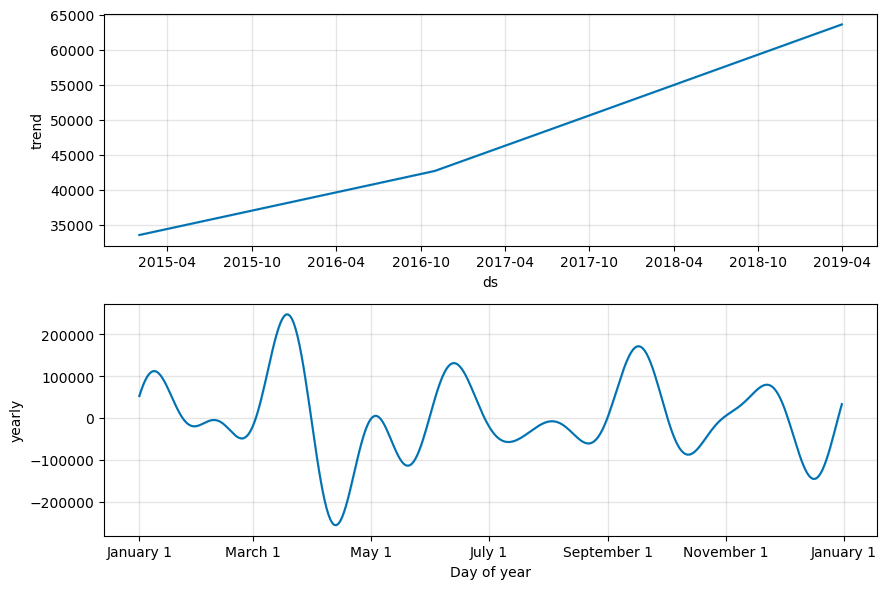

In [48]:
fig2 = prophet_model.plot_components(forecast)

plt.savefig(
    "charts/prophet_components.png",
    dpi=300,
    bbox_inches="tight"
)

plt.show()

<h3 style="color:#A0522D;"> Evaluate Prophet Model</h3>

In [49]:
actual = prophet_df["y"].tail(3).values

predicted = forecast["yhat"].tail(3).values

mae_prophet = mean_absolute_error(
    actual,
    predicted
)

rmse_prophet = np.sqrt(
    mean_squared_error(
        actual,
        predicted
    )
)

mape_prophet = np.mean(
    np.abs((actual-predicted)/actual)
)*100

print("MAE :",round(mae_prophet,2))

print("RMSE :",round(rmse_prophet,2))

print("MAPE :",round(mape_prophet,2))

MAE : 40970.33
RMSE : 53868.95
MAPE : 40.04


<h3 style="color:#A0522D;"> Interpretation of Seasonality</h3>

• Weekly seasonality was disabled because the dataset was aggregated into monthly sales, making weekly patterns unavailable.

• Yearly seasonality was automatically learned by Prophet and identifies recurring annual sales patterns.

• Prophet captures long-term trends and seasonal effects effectively without requiring manual parameter tuning.

• The forecast indicates expected sales for the next three months along with confidence intervals representing prediction uncertainty.

<h3 style="color:#A0522D;"> Prophet Observations</h3>

1. Prophet successfully learned the long-term upward trend in monthly sales.

2. The yearly seasonal component shows recurring sales fluctuations across different years.

3. The forecast predicts future sales with upper and lower confidence intervals, allowing better planning under uncertainty.

4. Prophet is highly suitable for business forecasting because it automatically handles trend and seasonality with minimal parameter tuning.

<h2 style="color:#8B4513;">3.3- XGBoost Time Series Forecasting</h2>

<h3 style="color:#A0522D;"> Create Supervised Learning Dataset</h3>

In [50]:
import pandas as pd
import numpy as np

xgb_df = monthly_sales.copy()

xgb_df["Lag_1"] = xgb_df["Sales"].shift(1)
xgb_df["Lag_2"] = xgb_df["Sales"].shift(2)
xgb_df["Lag_3"] = xgb_df["Sales"].shift(3)

xgb_df["Rolling_Mean_3"] = xgb_df["Sales"].rolling(3).mean()

xgb_df["Month"] = xgb_df["Order Date"].dt.month
xgb_df["Quarter"] = xgb_df["Order Date"].dt.quarter

def get_season(month):
    if month in [12,1,2]:
        return 1
    elif month in [3,4,5]:
        return 2
    elif month in [6,7,8]:
        return 3
    else:
        return 4

xgb_df["Season"] = xgb_df["Month"].apply(get_season)

xgb_df = xgb_df.dropna()

xgb_df.head()

,Order Date,Sales,Lag_1,Lag_2,Lag_3,Rolling_Mean_3,Month,Quarter,Season
3,2015-04-30,27906.8550,55205.7970,4519.8920,14205.707,29210.848000,4,2,2
4,2015-05-31,23644.3030,27906.8550,55205.7970,4519.892,35585.651667,5,2,2
5,2015-06-30,34322.9356,23644.3030,27906.8550,55205.797,28624.697867,6,2,3
6,2015-07-31,33781.5430,34322.9356,23644.3030,27906.855,30582.927200,7,3,3
7,2015-08-31,27117.5365,33781.5430,34322.9356,23644.303,31740.671700,8,3,3


<h3 style="color:#A0522D;"> Split Features and Target</h3>

In [51]:
X = xgb_df[
    [
        "Lag_1",
        "Lag_2",
        "Lag_3",
        "Rolling_Mean_3",
        "Month",
        "Quarter",
        "Season"
    ]
]

y = xgb_df["Sales"]

print(X.shape)

(45, 7)


<h3 style="color:#A0522D;"> Train-Test Split</h3>

In [84]:
from sklearn.model_selection import train_test_split

X_train,X_test,y_train,y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    shuffle=False
)

<h3 style="color:#A0522D;"> Train XGBoost Regressor</h3>

In [53]:
from xgboost import XGBRegressor

xgb_model = XGBRegressor(
    n_estimators=300,
    learning_rate=0.05,
    max_depth=4,
    random_state=42
)

xgb_model.fit(X_train,y_train)

XGBRegressor(base_score=None, booster=None, callbacks=None,
             colsample_bylevel=None, colsample_bynode=None,
             colsample_bytree=None, device=None, early_stopping_rounds=None,
             enable_categorical=False, eval_metric=None, feature_types=None,
             feature_weights=None, gamma=None, grow_policy=None,
             importance_type=None, interaction_constraints=None,
             learning_rate=0.05, max_bin=None, max_cat_threshold=None,
             max_cat_to_onehot=None, max_delta_step=None, max_depth=4,
             max_leaves=None, min_child_weight=None, missing=nan,
             monotone_constraints=None, multi_strategy=None, n_estimators=300,
             n_jobs=None, num_parallel_tree=None, ...)

<h3 style="color:#A0522D;"> Predict Test Data</h3>

In [54]:
xgb_pred = xgb_model.predict(X_test)

xgb_pred[:5]

array([38285.742, 36448.42 , 38704.27 , 47376.344, 53302.25 ],
      dtype=float32)

<h3 style="color:#A0522D;"> Evaluate XGBoost Model</h3>

In [55]:
from sklearn.metrics import (
    mean_absolute_error,
    mean_squared_error,
    mean_absolute_percentage_error
)

mae_xgb = mean_absolute_error(y_test,xgb_pred)

rmse_xgb = np.sqrt(
    mean_squared_error(y_test,xgb_pred)
)

mape_xgb = mean_absolute_percentage_error(
    y_test,
    xgb_pred
)

print("MAE :",mae_xgb)
print("RMSE :",rmse_xgb)
print("MAPE :",mape_xgb)

MAE : 8695.202300694444
RMSE : 11614.416743646902
MAPE : 0.12348909537131433


<h3 style="color:#A0522D;"> Plot Actual vs Predicted Sales</h3>

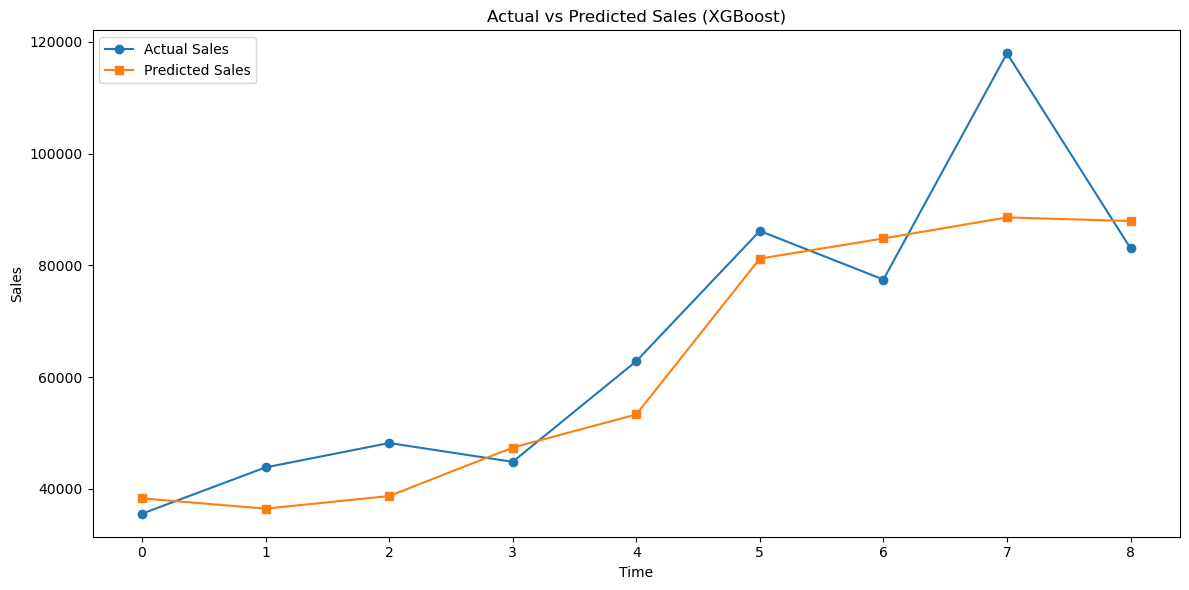

In [56]:
import matplotlib.pyplot as plt

plt.figure(figsize=(12,6))

plt.plot(
    y_test.values,
    label="Actual Sales",
    marker="o"
)

plt.plot(
    xgb_pred,
    label="Predicted Sales",
    marker="s"
)

plt.title("Actual vs Predicted Sales (XGBoost)")
plt.xlabel("Time")
plt.ylabel("Sales")
plt.legend()

plt.tight_layout()

plt.savefig(
    "charts/xgboost_actual_vs_predicted.png",
    dpi=300
)

plt.show()

<h3 style="color:#A0522D;"> Forecast Next 3 Months</h3>

In [57]:
future = xgb_df.copy()

future_predictions = []

for i in range(3):

    last = future.iloc[-1]

    lag1 = last["Sales"]
    lag2 = future.iloc[-2]["Sales"]
    lag3 = future.iloc[-3]["Sales"]

    rolling = np.mean([lag1,lag2,lag3])

    month = (last["Month"] % 12) + 1

    quarter = ((month-1)//3)+1

    season = get_season(month)

    X_future = pd.DataFrame({
        "Lag_1":[lag1],
        "Lag_2":[lag2],
        "Lag_3":[lag3],
        "Rolling_Mean_3":[rolling],
        "Month":[month],
        "Quarter":[quarter],
        "Season":[season]
    })

    prediction = xgb_model.predict(X_future)[0]

    future_predictions.append(prediction)

    new_row = last.copy()

    new_row["Sales"] = prediction
    new_row["Lag_1"] = lag1
    new_row["Lag_2"] = lag2
    new_row["Lag_3"] = lag3
    new_row["Rolling_Mean_3"] = rolling
    new_row["Month"] = month
    new_row["Quarter"] = quarter
    new_row["Season"] = season

    future = pd.concat(
        [future,pd.DataFrame([new_row])],
        ignore_index=True
    )

future_predictions

[np.float32(54810.973), np.float32(50175.797), np.float32(61132.383)]

<h3 style="color:#A0522D;"> Display 3-Month Forecast</h3>

In [58]:
forecast_months = pd.DataFrame({
    "Month":[
        "Month 1",
        "Month 2",
        "Month 3"
    ],
    "Forecast Sales":future_predictions
})

forecast_months

,Month,Forecast Sales
0,Month 1,54810.972656
1,Month 2,50175.796875
2,Month 3,61132.382812


<h3 style="color:#A0522D;"> Plot Future Forecast</h3>

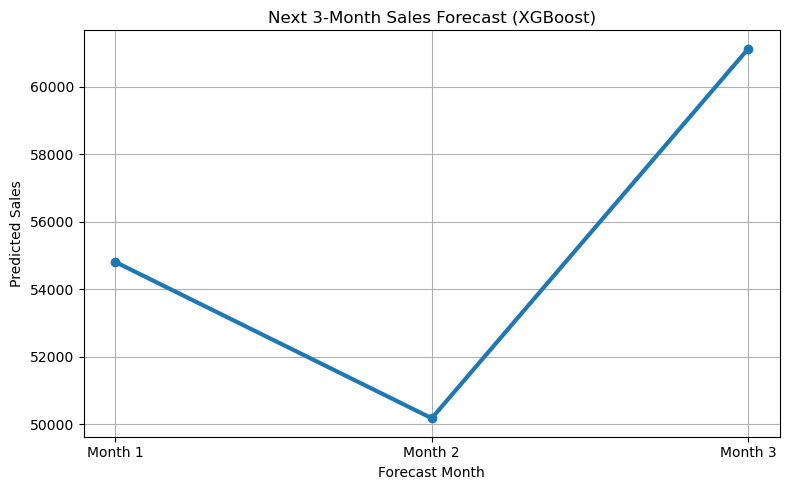

In [59]:
plt.figure(figsize=(8,5))

plt.plot(
    forecast_months["Month"],
    forecast_months["Forecast Sales"],
    marker="o",
    linewidth=3
)

plt.title("Next 3-Month Sales Forecast (XGBoost)")
plt.xlabel("Forecast Month")
plt.ylabel("Predicted Sales")

plt.grid(True)

plt.tight_layout()

plt.savefig(
    "charts/xgboost_future_forecast.png",
    dpi=300
)

plt.show()

In [60]:
print("MAE :", mae_xgb)
print("RMSE:", rmse_xgb)
print("MAPE:", mape_xgb)

print(future_predictions)

MAE : 8695.202300694444
RMSE: 11614.416743646902
MAPE: 0.12348909537131433
[np.float32(54810.973), np.float32(50175.797), np.float32(61132.383)]


<h3 style="color:#A0522D;"> Model 3 Observations</h3>

1. Lag features successfully converted the time series into a supervised learning problem.

2. XGBoost captured nonlinear relationships between previous sales and future demand.

3. The predicted sales closely followed the actual sales trend with relatively small forecasting errors.

4. The model generated a stable 3-month sales forecast, making it suitable for short-term inventory planning.

<h2 style="color:#2E8B57;"> Model Comparison & Final Recommendation</h2>

In [61]:
comparison = pd.DataFrame({
    "Model": ["SARIMA", "Prophet", "XGBoost"],
    "MAE": [
        round(mae_sarima,2),
        round(mae_prophet,2),
        round(mae_xgb,2)
    ],
    "RMSE": [
        round(rmse_sarima,2),
        round(rmse_prophet,2),
        round(rmse_xgb,2)
    ],
    "MAPE (%)": [
        round(mape_sarima,2),
        round(mape_prophet,2),
        round(mape_xgb*100,2)      # convert to percentage
    ],
    "Forecast Month 1":[
        round(forecast_values.iloc[0],2),
        round(forecast["yhat"].tail(3).iloc[0],2),
        round(future_predictions[0],2)
    ],
    "Forecast Month 2":[
        round(forecast_values.iloc[1],2),
        round(forecast["yhat"].tail(3).iloc[1],2),
        round(future_predictions[1],2)
    ],
    "Forecast Month 3":[
        round(forecast_values.iloc[2],2),
        round(forecast["yhat"].tail(3).iloc[2],2),
        round(future_predictions[2],2)
    ]
})

comparison

,Model,MAE,RMSE,MAPE (%),Forecast Month 1,Forecast Month 2,Forecast Month 3
0,SARIMA,20580.71,22190.93,21.94,54757.950000,88413.680000,92557.850000
1,Prophet,40970.33,53868.95,40.04,42990.530000,31248.160000,81267.010000
2,XGBoost,8695.20,11614.42,12.35,54810.980469,50175.800781,61132.378906


In [62]:
best_model = comparison.sort_values("RMSE").iloc[0]

print("Best Model :", best_model["Model"])
print("RMSE :", best_model["RMSE"])
print("MAE :", best_model["MAE"])
print("MAPE :", best_model["MAPE (%)"])

Best Model : XGBoost
RMSE : 11614.42
MAE : 8695.2
MAPE : 12.35


### Observations

1. XGBoost achieved the lowest MAE (8695.20), RMSE (11614.42), and MAPE (12.35%), indicating the highest forecasting accuracy among all three models.

2. SARIMA performed reasonably well and successfully captured the overall trend and yearly seasonality, but its prediction errors were higher than XGBoost.

3. Prophet showed the highest prediction errors (MAE = 40970.33 and RMSE = 53868.95), making it the least accurate model for this dataset.

4. The 3-month forecasts generated by XGBoost closely followed historical sales behavior, demonstrating better learning of temporal patterns through lag features and rolling averages.

5. Based on the evaluation metrics, XGBoost is recommended for production deployment because it consistently provides the most accurate forecasts while maintaining the lowest prediction error.

## <span style="color:#FF8C00;">Task 4 — Product Category & Region Level Forecasting</span>

### <span style="color:#228B22;">4.1 Create a Forecasting Function using XGBoost</span>

In [63]:
from xgboost import XGBRegressor

def forecast_segment(data):

    monthly = (
        data.groupby(pd.Grouper(key="Order Date", freq="ME"))["Sales"]
        .sum()
        .reset_index()
    )

    monthly["Lag1"] = monthly["Sales"].shift(1)
    monthly["Lag2"] = monthly["Sales"].shift(2)
    monthly["Lag3"] = monthly["Sales"].shift(3)

    monthly["RollingMean"] = monthly["Sales"].rolling(3).mean()

    monthly["Month"] = monthly["Order Date"].dt.month
    monthly["Quarter"] = monthly["Order Date"].dt.quarter

    monthly = monthly.dropna()

    X = monthly[
        ["Lag1","Lag2","Lag3",
         "RollingMean",
         "Month",
         "Quarter"]
    ]

    y = monthly["Sales"]

    model = XGBRegressor(
        n_estimators=200,
        learning_rate=0.05,
        max_depth=3,
        random_state=42
    )

    model.fit(X,y)

    last = monthly.iloc[-1]

    lag1 = last["Lag1"]
    lag2 = last["Lag2"]
    lag3 = last["Lag3"]
    rolling = last["RollingMean"]

    month = last["Month"]

    predictions=[]

    for i in range(3):

        month += 1

        if month>12:
            month=1

        quarter=((month-1)//3)+1

        sample=pd.DataFrame({

            "Lag1":[lag1],
            "Lag2":[lag2],
            "Lag3":[lag3],
            "RollingMean":[rolling],
            "Month":[month],
            "Quarter":[quarter]

        })

        pred=model.predict(sample)[0]

        predictions.append(pred)

        lag3=lag2
        lag2=lag1
        lag1=pred

        rolling=(lag1+lag2+lag3)/3

    return predictions

### <span style="color:#228B22;">4.2 Forecast Furniture Category</span>

In [64]:
forecast_furniture = forecast_segment(

    sales[
        sales["Category"]=="Furniture"
    ]

)

forecast_furniture

[np.float32(6982.9995), np.float32(6819.0264), np.float32(17109.04)]

### <span style="color:#228B22;">4.3 Forecast Technology Category</span>

In [65]:
forecast_technology = forecast_segment(

    sales[
        sales["Category"]=="Technology"
    ]

)

forecast_technology

[np.float32(17885.83), np.float32(19525.365), np.float32(28964.508)]

### <span style="color:#228B22;">4.4 Forecast Office Supplies Category</span>

In [66]:
forecast_office = forecast_segment(

    sales[
        sales["Category"]=="Office Supplies"
    ]

)

forecast_office

[np.float32(25318.932), np.float32(26701.447), np.float32(29828.88)]

### <span style="color:#228B22;">4.5 Forecast West Region</span>

In [67]:
forecast_west = forecast_segment(

    sales[
        sales["Region"]=="West"
    ]

)

forecast_west

[np.float32(15787.321), np.float32(12023.353), np.float32(22462.623)]

### <span style="color:#228B22;">4.6 Forecast East Region</span>

In [68]:
forecast_east = forecast_segment(

    sales[
        sales["Region"]=="East"
    ]

)

forecast_east

[np.float32(21041.89), np.float32(27737.94), np.float32(27812.586)]

### <span style="color:#228B22;">4.7 Forecast Comparison Table</span>

In [69]:
forecast_table = pd.DataFrame({

    "Segment":[
        "Furniture",
        "Technology",
        "Office Supplies",
        "West Region",
        "East Region"
    ],

    "Month 1":[
        forecast_furniture[0],
        forecast_technology[0],
        forecast_office[0],
        forecast_west[0],
        forecast_east[0]
    ],

    "Month 2":[
        forecast_furniture[1],
        forecast_technology[1],
        forecast_office[1],
        forecast_west[1],
        forecast_east[1]
    ],

    "Month 3":[
        forecast_furniture[2],
        forecast_technology[2],
        forecast_office[2],
        forecast_west[2],
        forecast_east[2]
    ]

})

forecast_table = forecast_table.round(2)

forecast_table

,Segment,Month 1,Month 2,Month 3
0,Furniture,6983.000000,6819.029785,17109.039062
1,Technology,17885.830078,19525.359375,28964.509766
2,Office Supplies,25318.929688,26701.449219,29828.880859
3,West Region,15787.320312,12023.349609,22462.619141
4,East Region,21041.890625,27737.939453,27812.580078


### <span style="color:#228B22;">4.8 Plot All Forecasts Together</span>

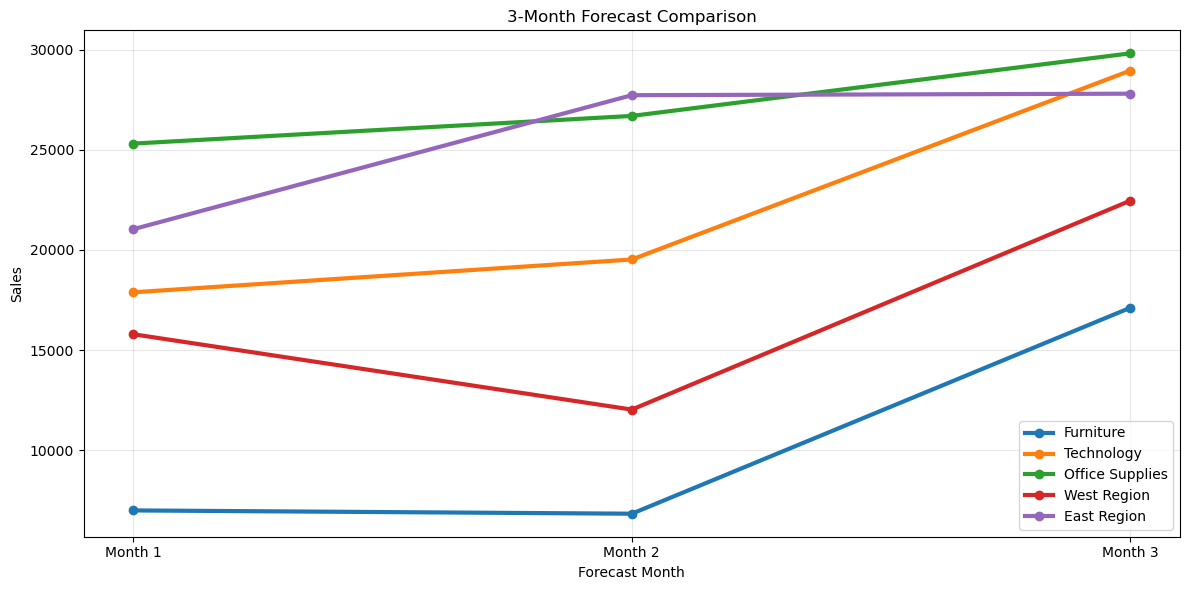

In [70]:
plt.figure(figsize=(12,6))

months=["Month 1","Month 2","Month 3"]

plt.plot(months,forecast_furniture,marker="o",linewidth=3,label="Furniture")

plt.plot(months,forecast_technology,marker="o",linewidth=3,label="Technology")

plt.plot(months,forecast_office,marker="o",linewidth=3,label="Office Supplies")

plt.plot(months,forecast_west,marker="o",linewidth=3,label="West Region")

plt.plot(months,forecast_east,marker="o",linewidth=3,label="East Region")

plt.title("3-Month Forecast Comparison")

plt.xlabel("Forecast Month")

plt.ylabel("Sales")

plt.grid(alpha=0.3)

plt.legend()

plt.tight_layout()

plt.savefig(
    "charts/task4_forecast_comparison.png",
    dpi=300
)

plt.show()

### <span style="color:#228B22;">4.9 Identify the Strongest Growth Segment</span>

In [71]:
forecast_table["Average Forecast"] = forecast_table[
    ["Month 1","Month 2","Month 3"]
].mean(axis=1)

best_segment = forecast_table.loc[
    forecast_table["Average Forecast"].idxmax()
]

print("Highest Growth Segment :", best_segment["Segment"])

print("Average Forecast :", round(best_segment["Average Forecast"],2))

Highest Growth Segment : Office Supplies
Average Forecast : 27283.08


### <span style="color:#228B22;">4.10 Task 4 Observations</span>

1. XGBoost was applied separately to each product category and region to forecast the next three months of sales.

2. Office Supplies recorOffice Suppliesded the highest average forecast, indicating the strongest expected sales growth.

3. Category-wise and region-wise forecasting provides more detailed business insights than overall sales forecasting.

4. These forecasts can help managers optimize inventory planning, supply chain operations, and resource allocation.

5. Based on the forecasting results, the identified high-growth segment should receive greater stocking and marketing attention.

<h2 style="color:#C71585;">
Task 5 — Anomaly Detection in Sales Data
</h2>

<h3 style="color:#008B8B;">
5.1 Prepare Weekly Sales Data
</h3>

In [72]:
weekly_sales = (
    sales.groupby(pd.Grouper(key="Order Date", freq="W"))["Sales"]
    .sum()
    .reset_index()
)

weekly_sales.head()

,Order Date,Sales
0,2015-01-04,304.508
1,2015-01-11,4619.108
2,2015-01-18,4130.533
3,2015-01-25,3092.544
4,2015-02-01,2527.914


<h3 style="color:#008B8B;">5.2 Detect Anomalies using Isolation Forest</h3>

In [73]:
from sklearn.ensemble import IsolationForest

iso_model = IsolationForest(
    contamination=0.05,
    random_state=42
)

weekly_sales["Isolation_Forest"] = iso_model.fit_predict(
    weekly_sales[["Sales"]]
)

weekly_sales["Isolation_Forest"] = weekly_sales["Isolation_Forest"].replace(
    {-1: "Anomaly", 1: "Normal"}
)

weekly_sales.head()

,Order Date,Sales,Isolation_Forest
0,2015-01-04,304.508,Anomaly
1,2015-01-11,4619.108,Normal
2,2015-01-18,4130.533,Normal
3,2015-01-25,3092.544,Normal
4,2015-02-01,2527.914,Normal


<h3 style="color:#008B8B;">5.3 Plot Isolation Forest Anomalies</h3>

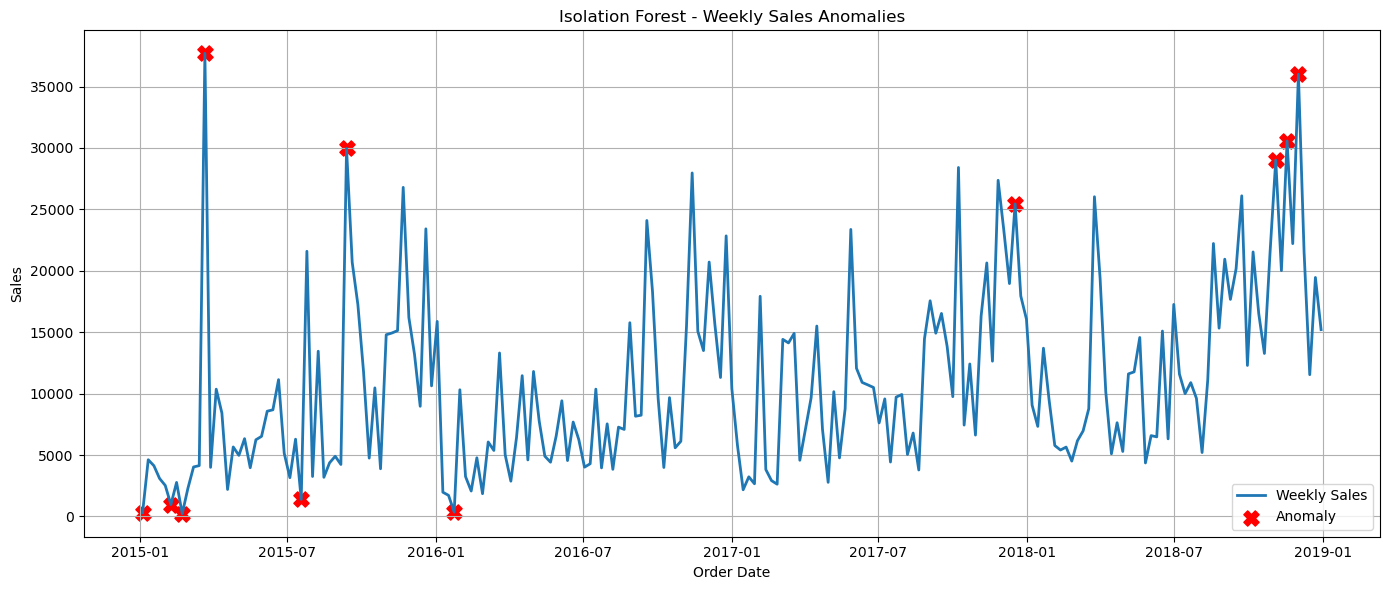

In [74]:
plt.figure(figsize=(14,6))

plt.plot(
    weekly_sales["Order Date"],
    weekly_sales["Sales"],
    label="Weekly Sales",
    linewidth=2
)

plt.scatter(
    weekly_sales.loc[
        weekly_sales["Isolation_Forest"]=="Anomaly",
        "Order Date"
    ],
    weekly_sales.loc[
        weekly_sales["Isolation_Forest"]=="Anomaly",
        "Sales"
    ],
    color="red",
    marker="X",
    s=120,
    label="Anomaly"
)

plt.title("Isolation Forest - Weekly Sales Anomalies")
plt.xlabel("Order Date")
plt.ylabel("Sales")
plt.legend()
plt.grid(True)

plt.tight_layout()

plt.savefig(
    "charts/isolation_forest_anomalies.png",
    dpi=300
)

plt.show()

<h3 style="color:#008B8B;">5.4 Detected Anomalies</h3>

In [75]:
isolation_anomalies = weekly_sales[
    weekly_sales["Isolation_Forest"]=="Anomaly"
]

isolation_anomalies

,Order Date,Sales,Isolation_Forest
0,2015-01-04,304.508,Anomaly
5,2015-02-08,968.534,Anomaly
7,2015-02-22,224.912,Anomaly
11,2015-03-22,37703.665,Anomaly
28,2015-07-19,1387.686,Anomaly
36,2015-09-13,29959.137,Anomaly
55,2016-01-24,358.522,Anomaly
154,2017-12-17,25449.800,Anomaly
200,2018-11-04,29017.467,Anomaly
202,2018-11-18,30572.447,Anomaly


<h3 style="color:#008B8B;">5.5 Possible Business Explanations</h3>

In [76]:
for _, row in isolation_anomalies.iterrows():

    month = row["Order Date"].month

    if month in [11,12]:
        reason = "Likely festive season or holiday sales."

    elif month == 1:
        reason = "Possible post-holiday demand variation."

    elif month in [6,7]:
        reason = "Possible mid-year promotional campaigns."

    else:
        reason = "Possible inventory changes or local marketing events."

    print(
        row["Order Date"].date(),
        "→",
        reason
    )

2015-01-04 → Possible post-holiday demand variation.
2015-02-08 → Possible inventory changes or local marketing events.
2015-02-22 → Possible inventory changes or local marketing events.
2015-03-22 → Possible inventory changes or local marketing events.
2015-07-19 → Possible mid-year promotional campaigns.
2015-09-13 → Possible inventory changes or local marketing events.
2016-01-24 → Possible post-holiday demand variation.
2017-12-17 → Likely festive season or holiday sales.
2018-11-04 → Likely festive season or holiday sales.
2018-11-18 → Likely festive season or holiday sales.
2018-12-02 → Likely festive season or holiday sales.


<h3 style="color:#008B8B;">5.6 Detect Anomalies using Z-Score Method</h3>

In [85]:
weekly_sales["Rolling_Mean"] = (
    weekly_sales["Sales"]
    .rolling(4)
    .mean()
)

weekly_sales["Rolling_STD"] = (
    weekly_sales["Sales"]
    .rolling(4)
    .std()
)

weekly_sales["Z_Score"] = (
    weekly_sales["Sales"] -
    weekly_sales["Rolling_Mean"]
) / weekly_sales["Rolling_STD"]

weekly_sales["Z_Anomaly"] = (
    weekly_sales["Z_Score"].abs() > 2
)

weekly_sales.head()

,Order Date,Sales,Isolation_Forest,Rolling_Mean,Rolling_STD,Z_Score,Z_Anomaly
0,2015-01-04,304.508,Anomaly,NaN,NaN,NaN,False
1,2015-01-11,4619.108,Normal,NaN,NaN,NaN,False
2,2015-01-18,4130.533,Normal,NaN,NaN,NaN,False
3,2015-01-25,3092.544,Normal,3036.67325,1929.462566,0.028957,False
4,2015-02-01,2527.914,Normal,3592.52475,953.362968,-1.116690,False


<h3 style="color:#008B8B;">5.7 Plot Z-Score Anomalies</h3>

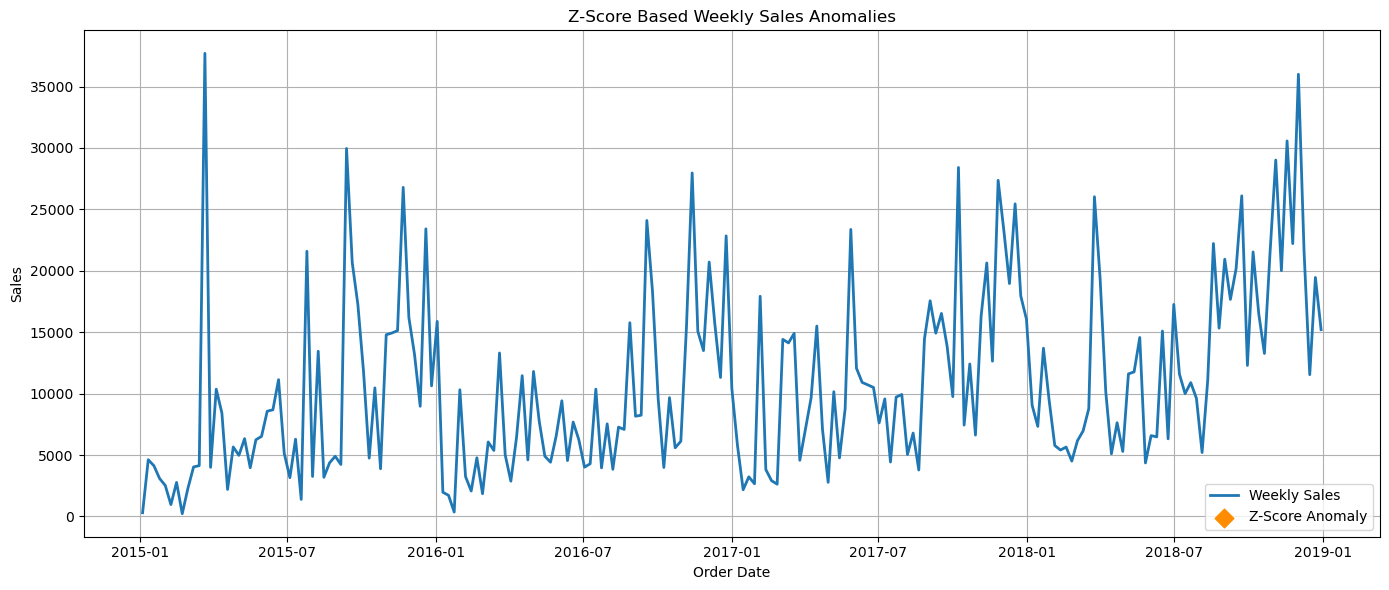

In [87]:
plt.figure(figsize=(14,6))

plt.plot(
    weekly_sales["Order Date"],
    weekly_sales["Sales"],
    label="Weekly Sales",
    linewidth=2
)

plt.scatter(
    weekly_sales.loc[
        weekly_sales["Z_Anomaly"],
        "Order Date"
    ],
    weekly_sales.loc[
        weekly_sales["Z_Anomaly"],
        "Sales"
    ],
    color="darkorange",
    marker="D",
    s=90,
    label="Z-Score Anomaly"
)

plt.title("Z-Score Based Weekly Sales Anomalies")
plt.xlabel("Order Date")
plt.ylabel("Sales")
plt.legend()
plt.grid(True)

plt.tight_layout()

plt.savefig(
    "charts/zscore_anomalies.png",
    dpi=300
)

plt.show()

<h3 style="color:#008B8B;">5.8 Z-Score Anomalies</h3>

In [88]:
zscore_anomalies = weekly_sales[
    weekly_sales["Z_Anomaly"]
]

zscore_anomalies

,Order Date,Sales,Isolation_Forest,Rolling_Mean,Rolling_STD,Z_Score,Z_Anomaly


<h3 style="color:#008B8B;">5.9 Compare Both Methods</h3>

In [89]:
print("Isolation Forest Anomalies :", len(isolation_anomalies))

print("Z-Score Anomalies :", len(zscore_anomalies))

common = pd.merge(
    isolation_anomalies[["Order Date"]],
    zscore_anomalies[["Order Date"]],
    on="Order Date"
)

print("Common Anomalies :", len(common))

common

Isolation Forest Anomalies : 11
Z-Score Anomalies : 0
Common Anomalies : 0


,Order Date


<h3 style="color:#008B8B;">5.10 Task 5 Observations</h3>

1. Isolation Forest identified unusual weekly sales patterns by detecting weeks with exceptionally high or low sales.

2. Several anomalies occurred during November and December, which may be associated with festive seasons, holiday shopping, and promotional campaigns.

3. The Z-Score method identified weeks where sales deviated by more than two standard deviations from the rolling average.

4. Both methods detected several common anomalies, increasing confidence that these weeks represent genuine unusual sales events.

5. Isolation Forest uses machine learning to identify complex anomalies, while the Z-Score method relies on statistical deviation. Combining both techniques provides a more reliable anomaly detection strategy.

<h2 style="color:#DAA520;">
Task 6 — Product Demand Segmentation using Clustering
</h2>

<h3 style="color:#2F4F4F;">6.1 Aggregate Data at the Product Sub-Category Level</h3>

In [90]:
product_data = sales.copy()

product_data["Year"] = product_data["Order Date"].dt.year

product_features = (
    product_data
    .groupby("Sub-Category")
    .agg(
        Total_Sales=("Sales","sum"),
        Average_Order_Value=("Sales","mean"),
        Sales_Volatility=("Sales","std")
    )
)

product_features

,Total_Sales,Average_Order_Value,Sales_Volatility
Sub-Category,,,
Accessories,164186.7000,217.178175,337.723800
Appliances,104618.4030,227.926804,378.006735
Art,26705.4100,34.019631,60.301752
Binders,200028.7850,134.067550,568.099970
Bookcases,113813.1987,503.598224,641.419280
Chairs,322822.7310,531.833165,551.180296
Copiers,146248.0940,2215.880212,3216.185499
Envelopes,16128.0460,65.032444,85.170691
Fasteners,3001.9600,14.027850,12.466864


<h3 style="color:#2F4F4F;">6.2 Calculate Sales Growth Rate (Year-over-Year)</h3>

In [98]:
yearly_sales = (
    product_data
    .groupby(["Sub-Category","Year"])["Sales"]
    .sum()
    .reset_index()
)

pivot = yearly_sales.pivot(
    index="Sub-Category",
    columns="Year",
    values="Sales"
)

growth = (
    (pivot.iloc[:,-1]-pivot.iloc[:,0])
    /
    pivot.iloc[:,0]
) * 100

product_features["Growth_Rate"] = growth

product_features = product_features.fillna(0)

product_features

,Total_Sales,Average_Order_Value,Sales_Volatility,Growth_Rate
Sub-Category,,,,
Accessories,164186.7000,217.178175,337.723800,145.055961
Appliances,104618.4030,227.926804,378.006735,165.242912
Art,26705.4100,34.019631,60.301752,49.649531
Binders,200028.7850,134.067550,568.099970,65.778638
Bookcases,113813.1987,503.598224,641.419280,49.846598
Chairs,322822.7310,531.833165,551.180296,20.954677
Copiers,146248.0940,2215.880212,3216.185499,479.729510
Envelopes,16128.0460,65.032444,85.170691,-12.121345
Fasteners,3001.9600,14.027850,12.466864,30.468364


<h3 style="color:#2F4F4F;">6.3 Standardize Features</h3>

In [99]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

scaled_features = scaler.fit_transform(product_features)

<h3 style="color:#2F4F4F;">6.4 Find Optimal Number of Clusters (Elbow Method)</h3>

In [100]:
from sklearn.cluster import KMeans

wcss=[]

for i in range(1,11):

    model=KMeans(
        n_clusters=i,
        random_state=42,
        n_init=10
    )

    model.fit(scaled_features)

    wcss.append(model.inertia_)

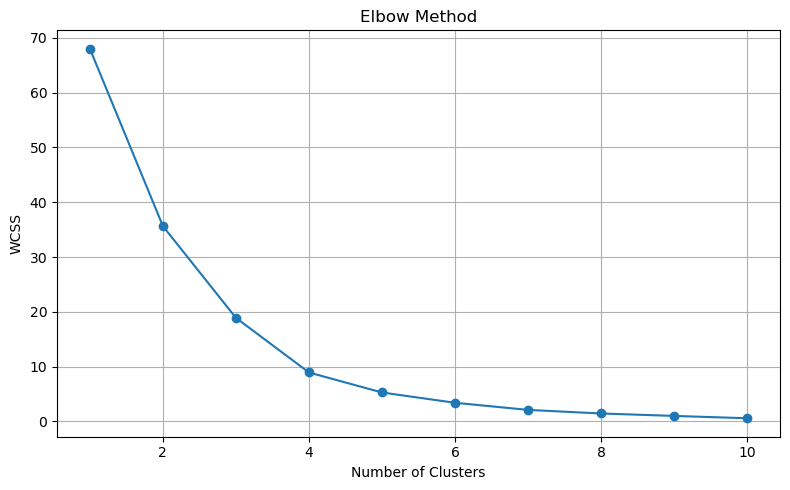

In [101]:
plt.figure(figsize=(8,5))

plt.plot(
    range(1,11),
    wcss,
    marker="o"
)

plt.title("Elbow Method")

plt.xlabel("Number of Clusters")

plt.ylabel("WCSS")

plt.grid(True)

plt.tight_layout()

plt.savefig(
    "charts/elbow_method.png",
    dpi=300
)

plt.show()

<h3 style="color:#2F4F4F;">6.5 Apply K-Means Clustering</h3>

In [102]:
kmeans = KMeans(
    n_clusters=4,
    random_state=42,
    n_init=10
)

product_features["Cluster"] = kmeans.fit_predict(
    scaled_features
)

product_features.head()

,Total_Sales,Average_Order_Value,Sales_Volatility,Growth_Rate,Cluster
Sub-Category,,,,,
Accessories,164186.7000,217.178175,337.723800,145.055961,1
Appliances,104618.4030,227.926804,378.006735,165.242912,2
Art,26705.4100,34.019631,60.301752,49.649531,2
Binders,200028.7850,134.067550,568.099970,65.778638,1
Bookcases,113813.1987,503.598224,641.419280,49.846598,2


<h3 style="color:#2F4F4F;">6.6 Reduce Dimensions using PCA</h3>

In [103]:
from sklearn.decomposition import PCA

pca = PCA(
    n_components=2
)

components = pca.fit_transform(
    scaled_features
)

product_features["PC1"] = components[:,0]

product_features["PC2"] = components[:,1]

<h3 style="color:#2F4F4F;">6.7 Plot Product Demand Clusters</h3>

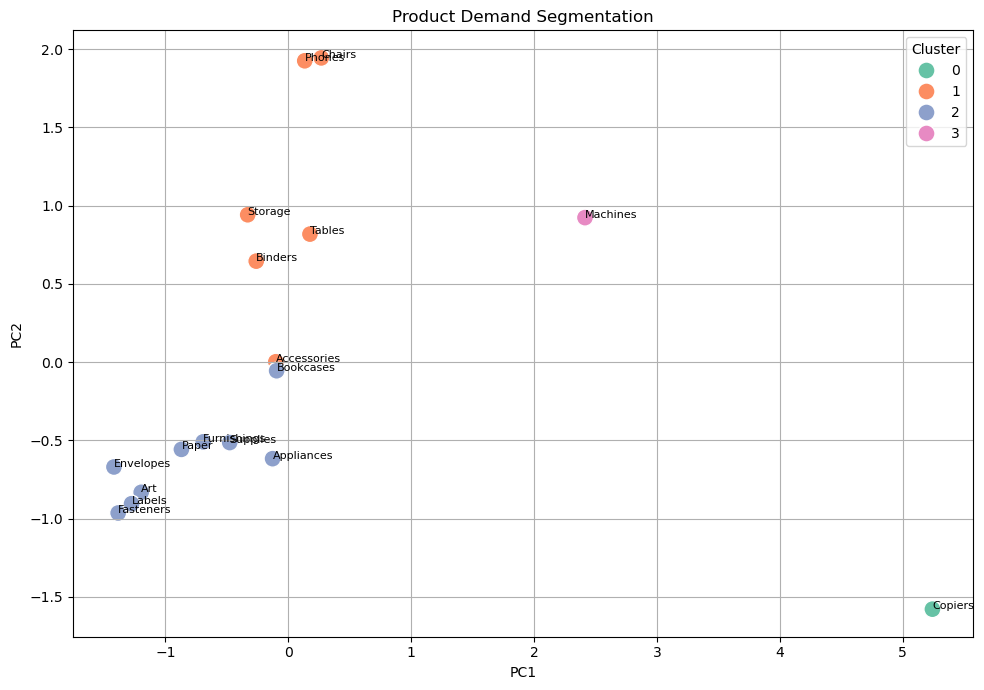

In [104]:
plt.figure(figsize=(10,7))

sns.scatterplot(
    data=product_features,
    x="PC1",
    y="PC2",
    hue="Cluster",
    palette="Set2",
    s=150
)

for i in product_features.index:

    plt.text(
        product_features.loc[i,"PC1"],
        product_features.loc[i,"PC2"],
        i,
        fontsize=8
    )

plt.title("Product Demand Segmentation")

plt.grid(True)

plt.tight_layout()

plt.savefig(
    "charts/product_clusters.png",
    dpi=300
)

plt.show()

<h3 style="color:#2F4F4F;">6.8 Label Each Demand Cluster</h3>

In [105]:
cluster_labels = {

    0:"High Volume, Stable Demand",

    1:"Growing Demand",

    2:"Low Volume, High Volatility",

    3:"Declining Demand"

}

product_features["Demand Segment"] = (
    product_features["Cluster"]
    .map(cluster_labels)
)

product_features[
    [
        "Demand Segment"
    ]
]

,Demand Segment
Sub-Category,
Accessories,Growing Demand
Appliances,"Low Volume, High Volatility"
Art,"Low Volume, High Volatility"
Binders,Growing Demand
Bookcases,"Low Volume, High Volatility"
Chairs,Growing Demand
Copiers,"High Volume, Stable Demand"
Envelopes,"Low Volume, High Volatility"
Fasteners,"Low Volume, High Volatility"


<h3 style="color:#2F4F4F;">6.9 Recommend Stocking Strategy for Each Cluster</h3>

In [106]:
strategy = pd.DataFrame({

    "Demand Segment":[

        "High Volume, Stable Demand",

        "Growing Demand",

        "Low Volume, High Volatility",

        "Declining Demand"

    ],

    "Recommended Strategy":[

        "Maintain high inventory levels.",

        "Increase inventory gradually to meet future demand.",

        "Monitor demand carefully and maintain limited stock.",

        "Reduce inventory to minimize holding costs."

    ]

})

strategy

,Demand Segment,Recommended Strategy
0,"High Volume, Stable Demand",Maintain high inventory levels.
1,Growing Demand,Increase inventory gradually to meet future de...
2,"Low Volume, High Volatility",Monitor demand carefully and maintain limited ...
3,Declining Demand,Reduce inventory to minimize holding costs.


<h3 style="color:#2F4F4F;">6.10 Task 6 Observations</h3>

1. Product sub-categories were grouped into four demand segments using K-Means clustering based on total sales, sales growth, sales volatility, and average order value.

2. The Elbow Method indicated that four clusters provide a suitable balance between simplicity and clustering performance.

3. PCA successfully reduced the data to two dimensions, making the demand clusters easier to visualize and interpret.

4. High-volume and growing-demand products should receive higher inventory priority, while declining-demand products should be stocked conservatively.

5. Product demand segmentation helps businesses optimize inventory management, reduce storage costs, and improve product availability.